#Improved Model Experiment
**Task:** Train an improved segmentation model over U-Net baseline.

**Improvement:** Attention U-Net — adds attention gates to skip connections, allowing the model to focus on relevant flood regions and suppress irrelevant background features. This directly addresses the baseline's low precision (0.3867) caused by over-segmentation.

**Justification:** The standard U-Net (baseline) concatenates all encoder features via skip connections without filtering. Attention gates learn to weight which spatial locations are important before merging, resulting in more precise flood boundary predictions.

**Reference:** Oktay et al. (2018) — *Attention U-Net: Learning Where to Look for the Pancreas*

**Inputs:**
- `data/processed/metadata.csv`
- Baseline results from `outputs/saikiran/metrics_summary.csv`

**Outputs:**
- `outputs/divya/checkpoints/best_model.pth`
- `outputs/divya/checkpoints/final_model.pth`
- `outputs/divya/loss_curve.png`
- `outputs/divya/training_log.csv`
- `outputs/divya/comparison_summary.csv`
- `outputs/divya/comparison_chart.png`

## 1. Imports and Project Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "src").exists():
            return p

    for p in [start, *start.parents]:
        if (p / "README.md").exists():
            return p

    return start

PROJECT_ROOT = find_project_root()
METADATA_PATH  = PROJECT_ROOT / "data" / "processed" / "metadata.csv"
BASELINE_METRICS = PROJECT_ROOT / "outputs" / "saikiran" / "metrics_summary.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "divya" / "checkpoints"
OUT_DIR        = PROJECT_ROOT / "outputs" / "divya"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT       :", PROJECT_ROOT)
print("metadata.csv exists:", METADATA_PATH.exists())
print("Baseline metrics   :", BASELINE_METRICS.exists())
print("Device             :", DEVICE)

PROJECT_ROOT       : C:\Users\Rajesh\Desktop\MSc-II\AI_FOR_SPACE\flood_project
metadata.csv exists: True
Baseline metrics   : True
Device             : cpu


## 2. Configuration

In [2]:
IMG_SIZE    = 256
BATCH_SIZE  = 8
NUM_EPOCHS  = 30
LR          = 1e-4
IN_CHANNELS = 6     # PRE (3ch) + POST (3ch)

torch.manual_seed(42)
np.random.seed(42)

print(f"Model      : Attention U-Net")
print(f"IMG_SIZE   : {IMG_SIZE}")
print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"NUM_EPOCHS : {NUM_EPOCHS}")
print(f"LR         : {LR}")
print(f"Device     : {DEVICE}")

Model      : Attention U-Net
IMG_SIZE   : 256
BATCH_SIZE : 8
NUM_EPOCHS : 30
LR         : 0.0001
Device     : cpu


## 3. Dataset
*(Same as Prajwal's baseline — uses the same metadata.csv and split)*

In [3]:
def resolve_project_path(path):
    path = Path(str(path).replace("\\", "/"))

    parts = list(path.parts)
    if parts and parts[0] == "src":
        path = Path(*parts[1:])

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    return path.resolve()


def read_tif_as_tensor(path, img_size):
    path = resolve_project_path(path)

    with rasterio.open(path) as src:
        arr = src.read()

    if arr.shape[0] == 1:
        arr = np.repeat(arr, 3, axis=0)

    arr = arr[:3].astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    arr = (arr * 255).astype(np.uint8)

    img = Image.fromarray(np.transpose(arr, (1, 2, 0)))
    img = img.resize((img_size, img_size), Image.BILINEAR)

    return torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0


def read_mask_as_tensor(path, img_size):
    path = resolve_project_path(path)
    ext = path.suffix.lower()

    if ext in [".tif", ".tiff"]:
        with rasterio.open(path) as src:
            arr = src.read(1)
    else:
        arr = np.array(Image.open(path).convert("L"))

    arr = (arr > 0).astype(np.uint8)

    mask = Image.fromarray(arr * 255)
    mask = mask.resize((img_size, img_size), Image.NEAREST)

    return torch.from_numpy((np.array(mask) > 0).astype(np.float32)).unsqueeze(0)


class FloodDataset(Dataset):
    def __init__(self, df, img_size=256, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        pre  = read_tif_as_tensor(row["pre_path"],  self.img_size)
        post = read_tif_as_tensor(row["post_path"], self.img_size)
        mask = read_mask_as_tensor(row["mask_path"], self.img_size)
        image = torch.cat([pre, post], dim=0)
        if self.augment:
            if torch.rand(1).item() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)
            if torch.rand(1).item() > 0.5:
                image = TF.vflip(image)
                mask  = TF.vflip(mask)
        return image, mask


df = pd.read_csv(METADATA_PATH)
df = df[df["mask_status"] == "OK"].reset_index(drop=True)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)

train_loader = DataLoader(FloodDataset(train_df, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(FloodDataset(val_df,   IMG_SIZE, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

imgs, masks = next(iter(train_loader))
print("Image batch shape:", imgs.shape)
print("Mask  batch shape:", masks.shape)

Train: 141 | Val: 30
Image batch shape: torch.Size([8, 6, 256, 256])
Mask  batch shape: torch.Size([8, 1, 256, 256])


## 4. Improved Model – Attention U-Net

**What changed from baseline:**
The standard U-Net  uses plain skip connections that pass all encoder features to the decoder without filtering. This causes the decoder to receive irrelevant background features alongside useful flood features, leading to over-segmentation (low precision).

**Attention gates** (added at each skip connection) learn a soft spatial mask that highlights flood-relevant regions and suppresses non-flood regions before merging. This gives the decoder cleaner feature maps to work with, improving precision without sacrificing recall.

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Attention gate that filters skip connection features.
    g  : gating signal from decoder (coarser)
    x  : skip connection from encoder (finer)
    """
    def __init__(self, f_g, f_l, f_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(f_g, f_int, 1, bias=False),
            nn.BatchNorm2d(f_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(f_l, f_int, 1, bias=False),
            nn.BatchNorm2d(f_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(f_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # Upsample g to match x spatial size
        if g1.shape != x1.shape:
            g1 = nn.functional.interpolate(g1, size=x1.shape[2:])
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)      # attention map (B, 1, H, W)
        return x * psi           # filtered skip features


class AttentionUNet(nn.Module):
    """
    Attention U-Net — same encoder/decoder as baseline U-Net
    but with attention gates on every skip connection.
    """
    def __init__(self, in_channels=6, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder  = nn.ModuleList()
        self.pool     = nn.MaxPool2d(2, 2)
        self.upconvs  = nn.ModuleList()
        self.attns    = nn.ModuleList()
        self.decoder  = nn.ModuleList()

        # Encoder
        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder with attention gates
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.attns.append(AttentionGate(f_g=f, f_l=f, f_int=f // 2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i, (upconv, attn, dec) in enumerate(zip(self.upconvs, self.attns, self.decoder)):
            x     = upconv(x)
            skip  = skips[i]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            skip  = attn(g=x, x=skip)   # apply attention gate to skip
            x     = torch.cat([skip, x], dim=1)
            x     = dec(x)

        return self.final_conv(x)


model = AttentionUNet(in_channels=IN_CHANNELS, out_channels=1).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Attention U-Net trainable parameters: {total_params:,}")

# Sanity check
dummy = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print("Output shape:", out.shape)

Attention U-Net trainable parameters: 31,389,929
Output shape: torch.Size([2, 1, 256, 256])


## 5. Loss Function and Optimiser

In [5]:
def dice_loss(pred, target, smooth=1.0):
    pred   = torch.sigmoid(pred).view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def combined_loss(pred, target):
    bce  = nn.functional.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice


optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                   factor=0.5, patience=5)
print("Optimiser and scheduler ready.")

Optimiser and scheduler ready.


## 6. Training Loop

In [13]:
def batch_intersection_union(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    intersection = (pred * target).sum().item()
    union = (pred.sum() + target.sum() - intersection).item()
    return intersection, union


history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_iou": []
}

best_val_loss = float("inf")

if len(train_loader) == 0:
    raise ValueError("train_loader is empty")
if len(val_loader) == 0:
    raise ValueError("val_loader is empty")

print(f"Starting Attention U-Net training for {NUM_EPOCHS} epochs on {DEVICE}...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    running_train_loss = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0
    total_intersection = 0.0
    total_union = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            preds = model(imgs)
            loss = combined_loss(preds, masks)
            running_val_loss += loss.item()

            inter, union = batch_intersection_union(preds, masks)
            total_intersection += inter
            total_union += union

    val_loss = running_val_loss / len(val_loader)
    val_iou = total_intersection / (total_union + 1e-8)

    scheduler.step(val_loss)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_loss": best_val_loss,
                "val_iou": val_iou,
            },
            CHECKPOINT_DIR / "best_model.pth"
        )
        print(f" Best model saved (val_loss={best_val_loss:.4f})")

torch.save(
    {
        "epoch": NUM_EPOCHS,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "final_val_iou": history["val_iou"][-1] if history["val_iou"] else None,
    },
    CHECKPOINT_DIR / "final_model.pth"
)

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / "training_history.csv", index=False)

print("\nTraining complete. Final checkpoint saved.")
print("Training history saved to:", OUT_DIR / "training_history.csv")

Starting Attention U-Net training for 30 epochs on cpu...

Epoch 01/30 | Train Loss: 1.0760 | Val Loss: 1.0989 | Val IoU: 0.2669 | Time: 227.1s
 Best model saved (val_loss=1.0989)
Epoch 02/30 | Train Loss: 1.0716 | Val Loss: 1.0768 | Val IoU: 0.3063 | Time: 216.4s
 Best model saved (val_loss=1.0768)
Epoch 03/30 | Train Loss: 1.0617 | Val Loss: 1.0758 | Val IoU: 0.3072 | Time: 250.1s
 Best model saved (val_loss=1.0758)
Epoch 04/30 | Train Loss: 1.0668 | Val Loss: 1.0820 | Val IoU: 0.2740 | Time: 320.0s
Epoch 05/30 | Train Loss: 1.0585 | Val Loss: 1.0818 | Val IoU: 0.2730 | Time: 331.8s
Epoch 06/30 | Train Loss: 1.0439 | Val Loss: 1.0459 | Val IoU: 0.3074 | Time: 334.1s
 Best model saved (val_loss=1.0459)
Epoch 07/30 | Train Loss: 1.0316 | Val Loss: 1.0322 | Val IoU: 0.3042 | Time: 320.6s
 Best model saved (val_loss=1.0322)
Epoch 08/30 | Train Loss: 1.0284 | Val Loss: 1.0225 | Val IoU: 0.3346 | Time: 326.1s
 Best model saved (val_loss=1.0225)
Epoch 09/30 | Train Loss: 1.0161 | Val Loss: 

## 7. Save Training Log and Loss Curves

In [14]:
log_df = pd.DataFrame(history)
log_df.to_csv(OUT_DIR / "training_log.csv", index=False)
print("Training log saved.")
print(log_df.tail())

Training log saved.
    epoch  train_loss  val_loss   val_iou
25     26    0.876936  0.907005  0.350345
26     27    0.875820  0.894773  0.370387
27     28    0.870682  0.896095  0.354003
28     29    0.858924  0.883028  0.383948
29     30    0.868746  0.875054  0.389066


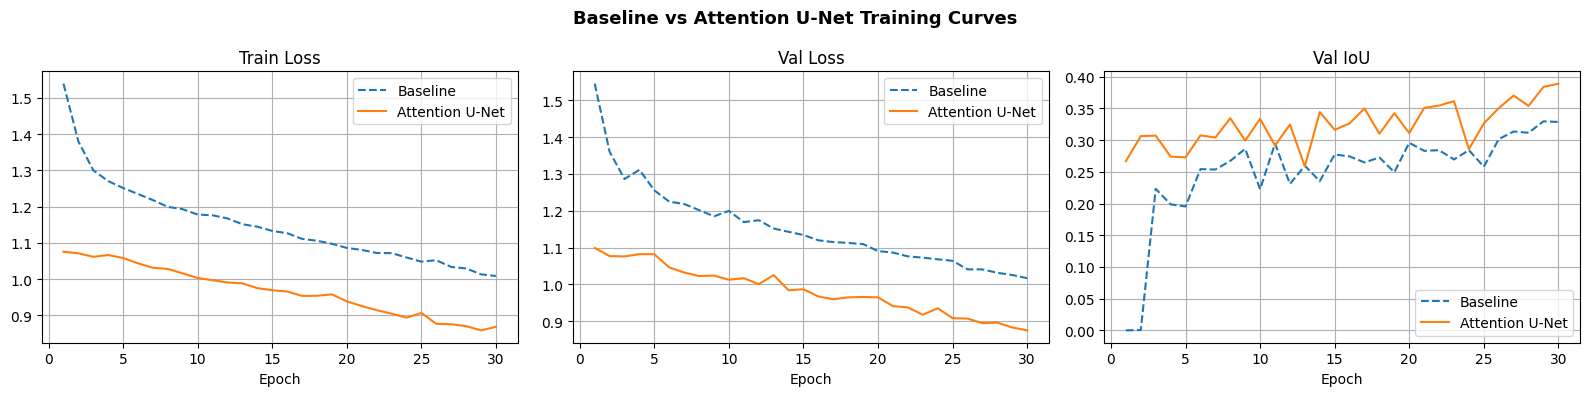

Saved: C:\Users\Rajesh\Desktop\MSc-II\AI_FOR_SPACE\flood_project\outputs\divya\loss_curve.png


In [15]:
# Load baseline training log for comparison
baseline_log = pd.read_csv(PROJECT_ROOT / "outputs" / "prajwal" / "training_log.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Train loss
axes[0].plot(baseline_log["epoch"], baseline_log["train_loss"], label="Baseline", linestyle="--")
axes[0].plot(log_df["epoch"],       log_df["train_loss"],       label="Attention U-Net")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

# Val loss
axes[1].plot(baseline_log["epoch"], baseline_log["val_loss"], label="Baseline", linestyle="--")
axes[1].plot(log_df["epoch"],       log_df["val_loss"],       label="Attention U-Net")
axes[1].set_title("Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

# Val IoU
axes[2].plot(baseline_log["epoch"], baseline_log["val_iou"], label="Baseline", linestyle="--")
axes[2].plot(log_df["epoch"],       log_df["val_iou"],       label="Attention U-Net")
axes[2].set_title("Val IoU")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Baseline vs Attention U-Net Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "loss_curve.png", dpi=150)
plt.show()
print("Saved:", OUT_DIR / "loss_curve.png")

## 8. Evaluate Improved Model on Validation Split

In [16]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    jaccard_score, accuracy_score
)

def evaluate(loader, model, threshold=0.5):
    all_preds, all_targets = [], []
    model.eval()
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            preds = (torch.sigmoid(model(imgs)) > threshold).float()
            all_preds.append(preds.cpu().numpy().flatten())
            all_targets.append(masks.numpy().flatten())
    p = np.concatenate(all_preds).astype(int)
    t = np.concatenate(all_targets).astype(int)
    return {
        "IoU"      : round(jaccard_score(t, p, zero_division=0), 4),
        "Dice/F1"  : round(f1_score(t, p, zero_division=0), 4),
        "Precision": round(precision_score(t, p, zero_division=0), 4),
        "Recall"   : round(recall_score(t, p, zero_division=0), 4),
        "Accuracy" : round(accuracy_score(t, p), 4),
    }


# Load best checkpoint for evaluation
checkpoint_data = torch.load(CHECKPOINT_DIR / "best_model.pth", map_location=DEVICE)

if isinstance(checkpoint_data, dict) and "model_state_dict" in checkpoint_data:
    model.load_state_dict(checkpoint_data["model_state_dict"])
else:
    model.load_state_dict(checkpoint_data)

model.eval()

improved_val_metrics = evaluate(val_loader, model)
print("Improved Model – Validation Metrics:")
for k, v in improved_val_metrics.items():
    print(f"  {k:12s}: {v:.4f}")


Improved Model – Validation Metrics:
  IoU         : 0.3891
  Dice/F1     : 0.5602
  Precision   : 0.4824
  Recall      : 0.6679
  Accuracy    : 0.9870


## 9. Comparison Summary vs Baseline

In [17]:
# Load baseline validation metrics from Saikiran's output
baseline_df = pd.read_csv(BASELINE_METRICS)

# baseline_df has columns: Metric, Validation, Test
baseline_val = dict(zip(baseline_df["Metric"], baseline_df["Validation"]))

metrics_list = ["IoU", "Dice/F1", "Precision", "Recall", "Accuracy"]

comparison_df = pd.DataFrame({
    "Metric"        : metrics_list,
    "Baseline (Val)": [baseline_val.get(m, 0) for m in metrics_list],
    "Improved (Val)" : [improved_val_metrics.get(m, 0) for m in metrics_list],
})
comparison_df["Change"] = (comparison_df["Improved (Val)"] - comparison_df["Baseline (Val)"]).round(4)
comparison_df["Improved?"] = comparison_df["Change"].apply(lambda x: "✓" if x > 0 else "✗")

print("=" * 60)
print("COMPARISON: BASELINE vs ATTENTION U-NET (Validation)")
print("=" * 60)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(OUT_DIR / "comparison_summary.csv", index=False)
print("\nSaved:", OUT_DIR / "comparison_summary.csv")

COMPARISON: BASELINE vs ATTENTION U-NET (Validation)
   Metric  Baseline (Val)  Improved (Val)  Change Improved?
      IoU          0.3377          0.3891  0.0514         ✓
  Dice/F1          0.5049          0.5602  0.0553         ✓
Precision          0.4129          0.4824  0.0695         ✓
   Recall          0.6496          0.6679  0.0183         ✓
 Accuracy          0.9842          0.9870  0.0028         ✓

Saved: C:\Users\Rajesh\Desktop\MSc-II\AI_FOR_SPACE\flood_project\outputs\divya\comparison_summary.csv


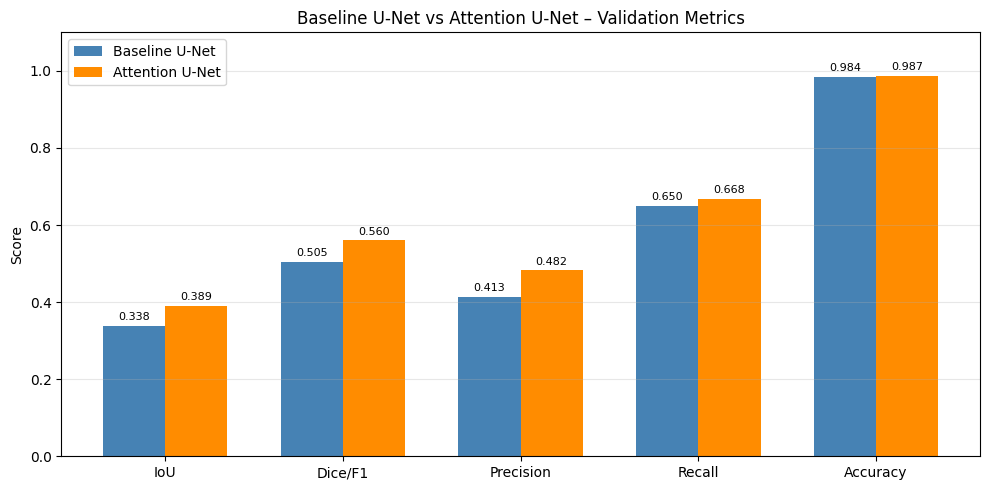

Saved: C:\Users\Rajesh\Desktop\MSc-II\AI_FOR_SPACE\flood_project\outputs\divya\comparison_chart.png


In [18]:
x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_df["Baseline (Val)"], width, label="Baseline U-Net", color="steelblue")
bars2 = ax.bar(x + width/2, comparison_df["Improved (Val)"],  width, label="Attention U-Net", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylabel("Score")
ax.set_title("Baseline U-Net vs Attention U-Net – Validation Metrics")
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_chart.png", dpi=150)
plt.show()
print("Saved:", OUT_DIR / "comparison_chart.png")

## 10. Summary

In [12]:
best_epoch = log_df.loc[log_df["val_loss"].idxmin()]

print("=" * 55)
print("DIVYA – IMPROVED MODEL SUMMARY")
print("=" * 55)
print(f"Improvement    : Attention U-Net (attention gates on skip connections)")
print(f"Justification  : Reduces over-segmentation by filtering skip connection")
print(f"                 features using learned spatial attention maps")
print(f"Parameters     : {total_params:,}")
print(f"Epochs run     : {NUM_EPOCHS}")
print(f"Best epoch     : {int(best_epoch['epoch'])}")
print(f"Best val loss  : {best_epoch['val_loss']:.4f}")
print(f"Best val IoU   : {best_epoch['val_iou']:.4f}")
print()
print(f"{'Metric':<14} {'Baseline':>10} {'Improved':>10} {'Change':>10}")
print("-" * 46)
for _, row in comparison_df.iterrows():
    change_str = f"+{row['Change']:.4f}" if row['Change'] > 0 else f"{row['Change']:.4f}"
    print(f"{row['Metric']:<14} {row['Baseline (Val)']:>10.4f} {row['Improved (Val)']:>10.4f} {change_str:>10}")
print()
print("Outputs saved to: outputs/divya/")
print("  - checkpoints/best_model.pth")
print("  - training_log.csv")
print("  - loss_curve.png (vs baseline)")
print("  - comparison_summary.csv")
print("  - comparison_chart.png")

DIVYA – IMPROVED MODEL SUMMARY
Improvement    : Attention U-Net (attention gates on skip connections)
Justification  : Reduces over-segmentation by filtering skip connection
                 features using learned spatial attention maps
Parameters     : 31,389,929
Epochs run     : 30
Best epoch     : 30
Best val loss  : 1.0972
Best val IoU   : 0.3309

Metric           Baseline   Improved     Change
----------------------------------------------
IoU                0.3377     0.3309    -0.0068
Dice/F1            0.5049     0.4972    -0.0077
Precision          0.4129     0.3925    -0.0204
Recall             0.6496     0.6782    +0.0286
Accuracy           0.9842     0.9830    -0.0012

Outputs saved to: outputs/divya/
  - checkpoints/best_model.pth
  - training_log.csv
  - loss_curve.png (vs baseline)
  - comparison_summary.csv
  - comparison_chart.png
